# Tuango - Targeting Mobile App Messages
Add text motivating your work in Markdown format. Markdown  To help you get started test and roll example available using the command below.

`usethis --name "rsm-mgta455-bbb-test-rollout" --dest "~/Desktop" --url "https://www.dropbox.com/scl/fo/si2at367p43hu6dodjtgb/ALvl7nJfcRDTdMGlFtmkiCE?rlkey=yx5nwcd3bottgw6vc3r9lqte8&dl=1"`

<!-- dropbox links updated 2025 -->

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import pyrsm as rsm
import seaborn as sns
import matplotlib.pyplot as plt

# you can import additional python packages but only use packages that
# are already part of the docker container

In [2]:
# Use this dataset and notebook to answer questions 1-13
tuango = pd.read_parquet("data/tuango_pre.parquet")
tuango

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test
0,U15889344,no,0.0,309,7.0,39.799999,44,F,yes,0.0,1
1,U60246497,no,0.0,297,8.0,39.799999,80,M,yes,1.0,1
2,U22965759,no,0.0,295,1.0,72.900002,59,F,yes,1.0,1
3,U40811142,no,0.0,277,1.0,40.000000,37,F,yes,0.0,1
4,U76283952,no,0.0,259,1.0,21.000000,43,F,yes,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
418155,U83013842,NaN,NaN,19,4.0,128.000000,25,F,yes,NaN,0
418156,U45426448,NaN,NaN,131,2.0,110.740000,20,O,yes,NaN,0
418157,U48935927,NaN,NaN,53,1.0,126.000000,71,M,no,NaN,0
418158,U94568595,NaN,NaN,12,4.0,98.000000,64,M,yes,NaN,0


In [3]:
# dataset description
tuango_description = rsm.md("data/tuango_pre_description.md")

data/tuango_pre_description.md

In [4]:
# you will likely find the below useful in this assignment
# there are missing values in the data that you will need to deal with
# why do you think there missing values?
# do you think there are data quality issues?
# or is there a simpler explanation?
tuango.buyer.value_counts(dropna=False)

buyer
NaN    397252
no      18888
yes      2020
Name: count, dtype: int64

In [5]:
# you will likely find the below useful in this assignment
tuango.buyer.isna().value_counts()

buyer
True     397252
False     20908
Name: count, dtype: int64

In [6]:
# tuango["buyer_yes"] = rsm.ifelse(tuango["buyer"] == "yes", 1, rsm.ifelse(tuango["buyer"] == "no", 0, np.nan))
# tuango.buyer_yes.value_counts(dropna=False)

In [7]:
# create a variable called 'buyer_yes' that has value 1 when buyer == 'yes', has value 0 when buyer == 'no' and has value np.nan when buyer.isna() is True
tuango["buyer_yes"] = tuango["buyer"].map({"yes": 1, "no": 0, np.nan: np.nan})

# you can check that you have this set up correctly using the command below
tuango.buyer_yes.value_counts(dropna=False)

tuango["buyer_yes"] = tuango["buyer_yes"].astype("float64")

## Part I:  Preliminary Analysis

### Question 1

What proportion of customers responded to the deal offer message (i.e., bought the deal)?

In [8]:
# insert calculation code here
# the result should be expressed as a proportion/decimal
# assign the calculated number to "q2"
# there is no need to round the result

q1 = tuango["buyer_yes"].mean()
q1

q = pd.crosstab(
    index=tuango.buyer[tuango.test == 1],
    columns = "response rate",
    normalize = "columns",
)
print(f"proportion of customers in sample that bouthgt a karaoke deal {q1.round(4)}")
print(q)


# q1 = tuango[tuango.test == 1].groupby("buyer").buyer.agg(n_obs = "count")
# q1["perc"] = q1/q1.sum()
# print(q1)

proportion of customers in sample that bouthgt a karaoke deal 0.0966
col_0  response rate
buyer               
yes         0.096614
no          0.903386


0.09661373636885402 of customers responded to the deal offer message 

### Question 2

What was the average number of karaoke sessions purchased by customers that bought one or more 30-minute sessions? Use the “ordersize” variable for your calculation (2 points)


In [9]:
# insert calculation code here to create a pd.pivot_table that shows
# (1) counts the number of yes and no, (2) the mean ordersize, and
# (3) the standard deviation in ordersize for yes and no responses
q2 = q1.copy()

q2 = pd.pivot_table(
    tuango,
    values=["ordersize"],
    index="buyer",
    aggfunc={"buyer": "count", "ordersize": ["mean","std"]},
    observed=False,
).round(4)
q2.columns = ["count", "mean", "std"]
print(q2)
# the below should show your result
# do not apply any rounding to your answer
q2.loc["yes", "mean"]


       count    mean     std
buyer                       
yes     2020  3.9411  1.7019
no     18888  0.0000  0.0000


3.9411

The average number of karaoke sessions purchased by customers that bought one or more 30-minute sessions is 3.9410891089108913

## Part II: Building Targeting Models
### Question 3

Estimate a logistic regression model using “buyer” as the response variable (aka target or dependent variable) and, recency, frequency, monetary, age, gender, and music as the explanatory variables (aka features or independent variables)

In [10]:
train_data = tuango[tuango["test"] == 1]
test_data = tuango[tuango["test"] == 0]

In [11]:
clf = rsm.model.logistic(
    data = {"train_data": train_data}, # use 5% of the data for training
    rvar = "buyer", 
    lev = "yes",
    evar = ["recency", "frequency", "monetary", "age", "gender", "music"]
)

clf.summary()

Logistic regression (GLM)
Data                 : train_data
Response variable    : buyer
Level                : yes
Explanatory variables: recency, frequency, monetary, age, gender, music
Null hyp.: There is no effect of x on buyer
Alt. hyp.: There is an effect of x on buyer

               OR     OR%  coefficient  std.error  z.value p.value     
Intercept   0.051  -94.9%        -2.98      0.097  -30.768  < .001  ***
gender[F]   1.731   73.1%         0.55      0.054   10.073  < .001  ***
gender[O]   1.078    7.8%         0.07      0.128    0.584   0.559     
music[yes]  1.908   90.8%         0.65      0.059   10.912  < .001  ***
recency     0.999   -0.1%        -0.00      0.000   -3.292  < .001  ***
frequency   1.114   11.4%         0.11      0.010   10.861  < .001  ***
monetary    1.002    0.2%         0.00      0.000   12.499  < .001  ***
age         0.988   -1.2%        -0.01      0.001   -9.115  < .001  ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo R-s

In [12]:
# clf = rsm.model.logistic(
#     data = {"tuango": tuango}, rvar = "buyer", evar = ["recency", "frequency", "monetary", "age", "gender", "music"]
# )

# clf.summary()

### Question 4

Create Prediction plots for all explanatory variables. Describe the effect of each explanatory variable on the probability that a customer will purchase the karaoke deal

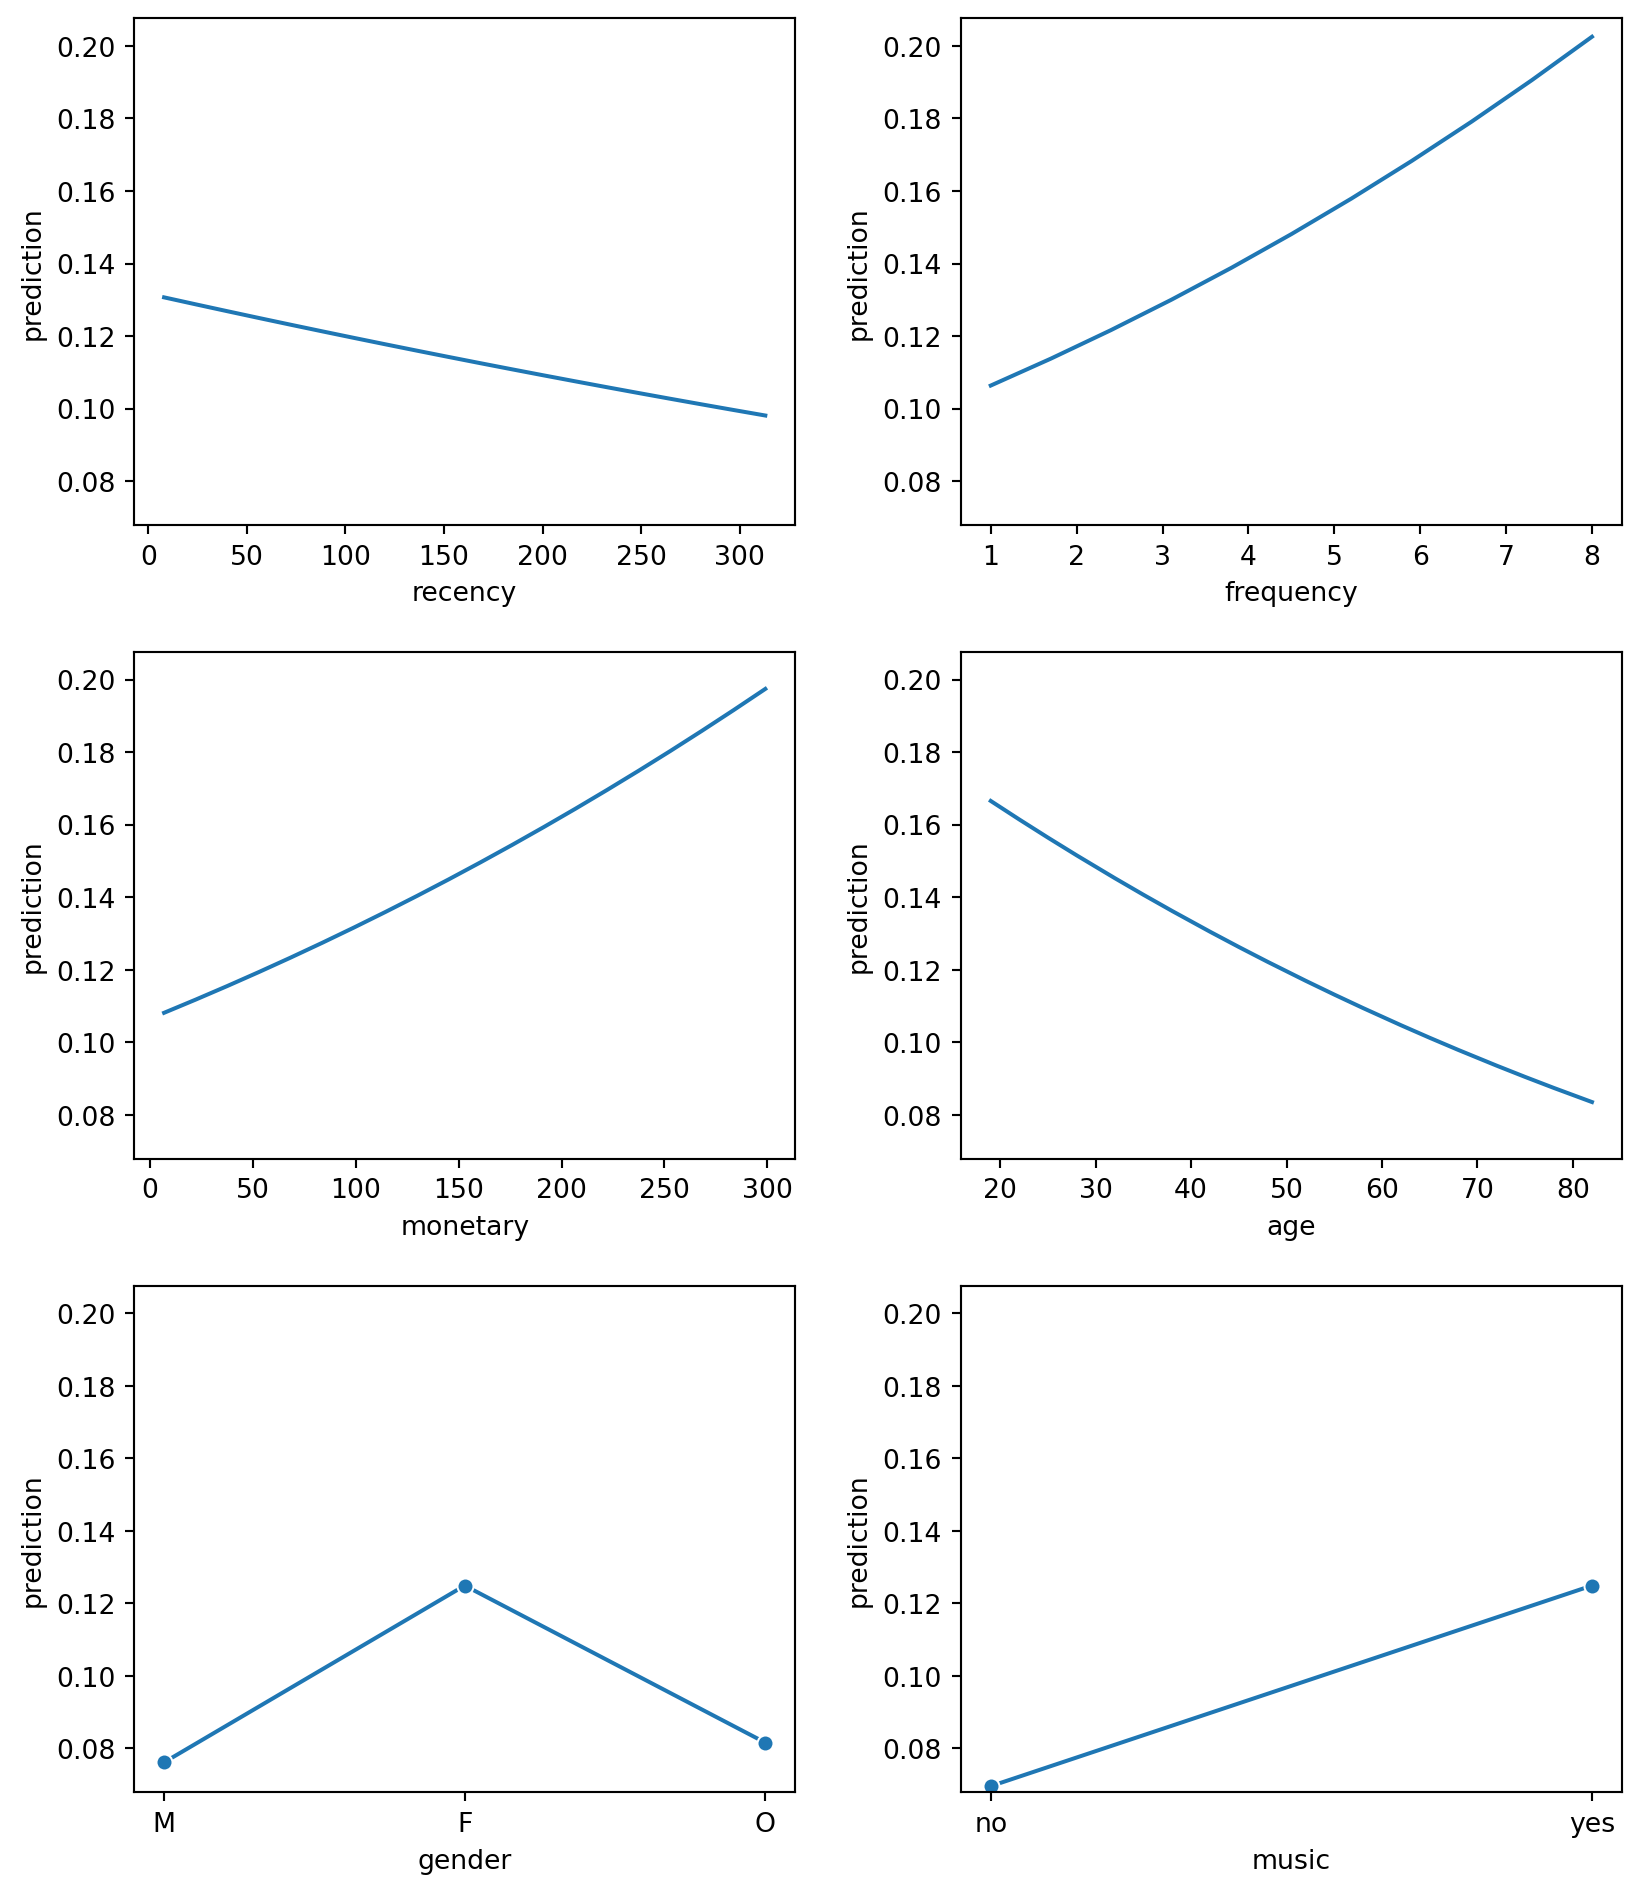

In [13]:
clf.plot("pred")

Recency: As recency increases, the probability of purchase decreases. This is because the longer it has been since the customer last purchased, the less likely they are to purchase again.

Frequency: As frequency increases, the probability of purchase increases. This is because the more frequently a customer purchases, the more likely they are to purchase again as a loyal customer

Monetary: As monetary value increases, the probability of purchase increases. This is because the more money a customer spends, the more likely 

Age: As age increases, the probability of purchase decreases. This is because older customers are less likely to purchase karaoke. younger customers are more likely to purchase

Gender: Female customers are most likely to purchase followed by other and the leas likely to purchase are men

Music: Customers who like music are more likely to purchase karaoke than those who don't

### Question 5

Use Permutation Importance to assess variable importance. Which variables seem to be most and least important in the model? Explain how Permutation Importance allows you to evaluate variable importance.

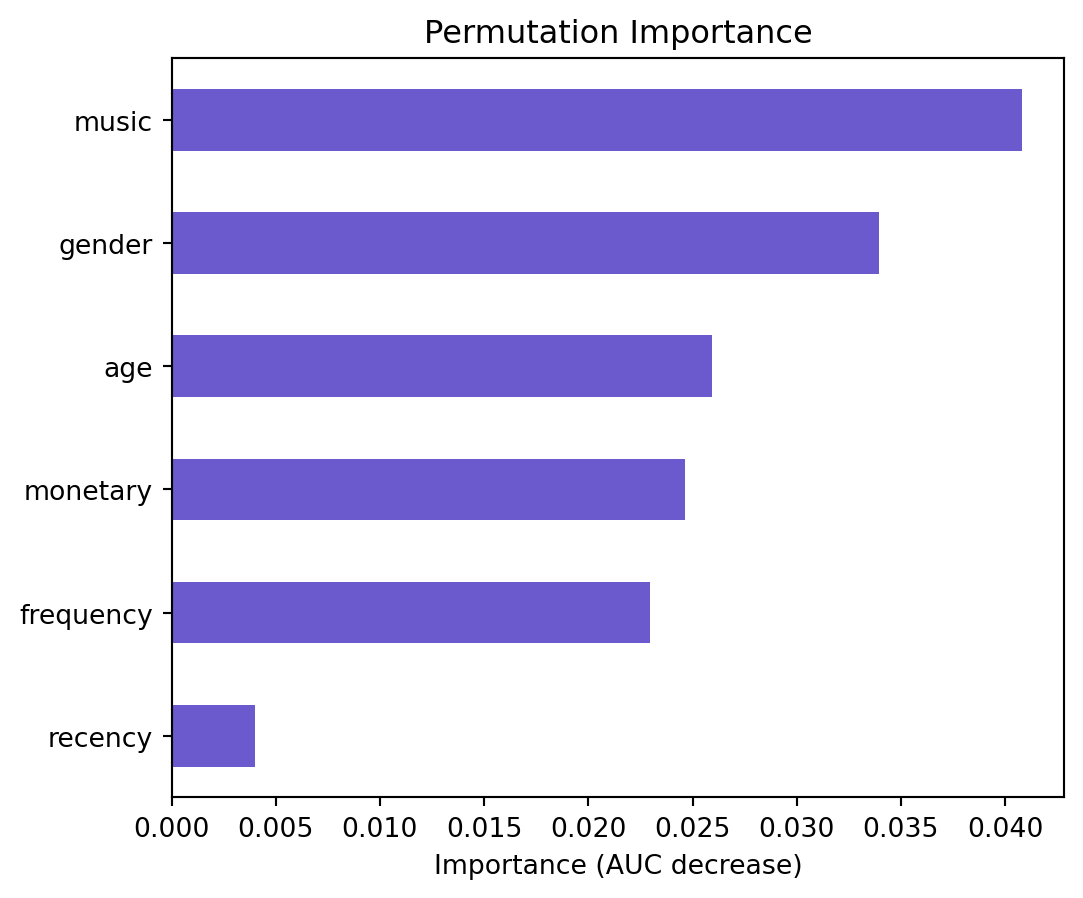

In [14]:
clf.plot("vimp")

Music seems like the most important variable in the model at 0.040, but this does not tell us if it is a positive or negative effect. On the other hand, recency is the least important variable in this model at less than 0.005. 

### Question 6

Add the predicted values from the logistic regression to the "tuango" DataFrame. Use "pred_logit" as the variable name. Compare the average of the predicted values to the overall response rate (i.e., proportion of buyers). What do you notice when you do this calculation using only the data used to estimate the model? Explain.

In [15]:
b = clf.predict(data = test_data)
b

,recency,frequency,monetary,age,gender,music,prediction
20908,8,1.0,115.330000,71,F,yes,0.092104
20909,274,1.0,58.000000,46,F,yes,0.083355
20910,185,8.0,123.599998,46,O,yes,0.134632
20911,127,3.0,87.810000,46,M,no,0.041179
20912,31,8.0,95.000000,33,F,yes,0.244048
...,...,...,...,...,...,...,...
418155,19,4.0,128.000000,25,F,yes,0.202410
418156,131,2.0,110.740000,20,O,yes,0.103399
418157,53,1.0,126.000000,71,M,no,0.029175
418158,12,4.0,98.000000,64,M,yes,0.077903


In [16]:
test_data["pred_logit"] = b["prediction"]

/tmp/ipykernel_17749/4294169774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["pred_logit"] = b["prediction"]


In [17]:
tuango["pred_logit"] = clf.predict(data = tuango)["prediction"]

In [18]:
avg_pred = test_data["pred_logit"].mean()
print(avg_pred)
print(q1)

0.09659918589483014
0.09661373636885402


In [19]:
tuango["pred_logit"] =  clf.predict(tuango)["prediction"]

It is the same value that we calculated in question 1. The average of the predicted values is 0.09661373636885402 which is the same as the overall response rate. This is because the model is predicting the probability of purchase based on the data used to estimate the model. So the predicted values are very similar to the actual values.The model is like to overfit and be like the observed data

### Question 7

Estimate a linear regression model using "ordersize" as the response variable and recency, frequency, monetary, age, gender, and music as the explanatory variables. Estimate this regression using only those customers who placed an order after the deal offer message. Describe why you think it does, or does not, make sense to focus on this group of customers

It does not makes sense to focus on this group. They should include all customers because we might overfit with just the focus group. We are evaluating the order size, not the effectivness of the deal offer message on the customers who placed an order. It can give targeted insights on which variables are most important in driving the increase in order sizes. Both groups may have different drivers, so by combining it, we van generalize this information to more customers in the future. Our goal is to discover overall behavior not just highly commited customers

In [20]:
tuango_ordered = tuango[tuango["buyer"] == "yes"]
# print(tuango_ordered)
reg = rsm.model.regress(
    data = {"tuango_ordered": tuango_ordered}, rvar = "ordersize", evar = ["recency", "frequency", "monetary", "age", "gender", "music"]
)

In [21]:
# reg = rsm.model.regress(
#     tuango[(tuango.buyer == "yes") & (tuango.test == 1)],
#     rvar = "ordersize",
#     evar = ["recency", "frequency", "monetary", "age", "gender", "music"]
# )
# reg.summary(main = False)
# correct way

In [22]:
reg.summary()

Linear regression (OLS)
Data                 : tuango_ordered
Response variable    : ordersize
Explanatory variables: recency, frequency, monetary, age, gender, music
Null hyp.: the effect of x on ordersize is zero
Alt. hyp.: the effect of x on ordersize is not zero

            coefficient  std.error  t.value p.value     
Intercept         3.665      0.174   21.104  < .001  ***
gender[F]         0.126      0.089    1.425   0.154     
gender[O]         0.259      0.208    1.243   0.214     
music[yes]        0.025      0.097    0.255   0.799     
recency           0.000      0.001    0.591   0.555     
frequency         0.023      0.016    1.456   0.145     
monetary          0.000      0.000    1.035   0.301     
age               0.001      0.003    0.389   0.697     

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.003, Adjusted R-squared: -0.0
F-statistic: 0.939 df(7, 2012), p.value 0.475
Nr obs: 2,020


### Question 8

Use Permutation Importance to assess variable importance. Which variables seem to be most important in the model?

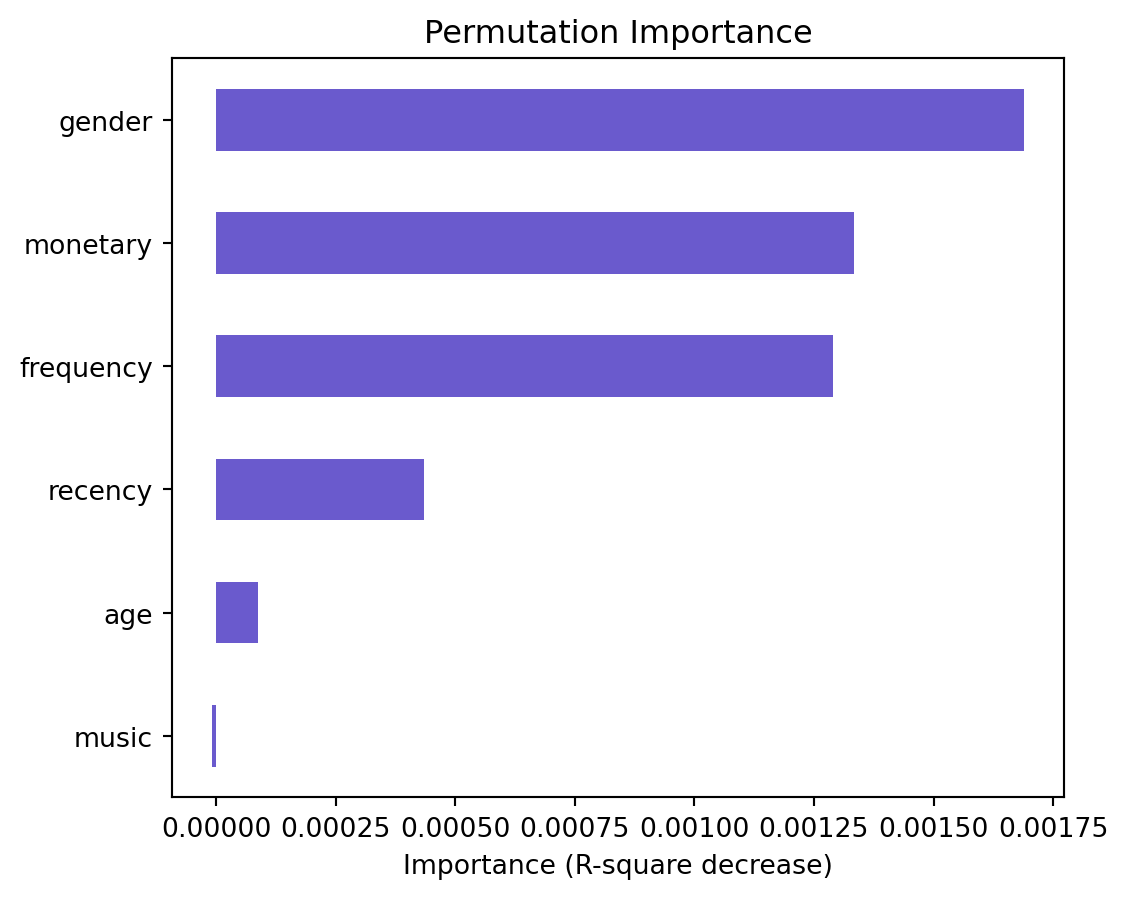

In [23]:
reg.plot("vimp")

Gender seems to be the most important variable at 0.00175, followed by monetary and frequency, which are very close to each other.

### Question 9

What do the linear regression model results suggest about our ability to predict ordersize for customers who responded to the deal?


Looking at the linear regression model, we can see that the R-squared value is 0.003, which means that the model does not explain the variance in the data. This means that the model is not able to predict ordersize for customers who responded to the deal. This model is not a good fit. None of the variables are statistically significant.

### Question 10

Add the predicted values from the linear regression to the "tuango" data.frame. Compare the average of the predicted values to the average value of ordersize. Make sure to focus only on buyers. What do you notice?

In [24]:
tuango["pred_linear"] = reg.predict()["prediction"]

tuango_filtered = tuango[tuango["buyer"] == "yes"]
avg_pred_ordersize = tuango_filtered["pred_linear"].mean()

print(avg_pred_ordersize)


3.941089108910902


In [25]:
tuango.loc[
           (tuango.test ==1) & (tuango.buyer == "yes"), 
           ["ordersize", "pred_linear"]].mean()

ordersize      3.941089
pred_linear    3.941089
dtype: float64

In [26]:
tuango.loc[
    (tuango.test == 1),
    ["buyer_yes", "pred_logit"]].mean()

buyer_yes     0.096614
pred_logit    0.096614
dtype: float64

This average is the same number that we calculated in question 2. This is because we used the same data for the regression model to predict it so it will be very similar.  

## Part III: Profitability Analysis

The following questions focus on the profit and return on marketing expenditures from offering the deal to (some of) the remaining 397,252 potential customers in Hangzhou (i.e., 418,160 – 20,908).

To calculate profit and return on marketing expenditures assume the following:
- Price per 30-minute session is 49 RMB
- Marginal cost of sending a deal offer message is 9 RMB
- Tuango’s fee on each deal sold is 50% of sales revenues

### Question 11

What is the breakeven response rate? Use the average ordersize from question 2 in your revenue calculations.

In [27]:
# state your assumptions that are relevant to calculate
# the breakeven response rate
# breakeven should be of type `float`

avg_ordersize = q2.loc["yes", "mean"]
# print(avg_ordersize)
cost = 9.0 # float
margin = 49 * 0.5 * avg_ordersize # float
breakeven = cost / margin # float, do not apply rounding, do not express as a percentage
q11 = breakeven # float, DO NOT APPLY ROUNDING, do not express as a percentage

# print(type(cost))
# print(type(margin))
# print(type(breakeven))
# print(type(q11))

print(cost)
print(margin)
print(breakeven)
print(q11) # anyone below threshold is not profitable 
# if avg response rate is larger than spamming method, it is profitable
# higher cost is better than too low cost, targeting is more effective, not annoying thousands of people

9.0
96.55695
0.09320924076412936
0.09320924076412936


The breakeven response rate is 0.09320949834524941

### Question 12

What is the projected profit in RMB and the return on marketing expenditures if you offer the deal to all 397,252 remaining customers (i.e., target everyone)?

In [28]:
# insert calculation code here
# all variables should be numeric (integer or float) and of length 1
# _all stands for 'targeting all'
tuango["message_all"] = True

ncust = tuango.groupby("buyer", observed = False).buyer.agg("count")

all = pd.DataFrame(
    {
        "n_obs": ncust,
        "perc": ncust.agg(lambda x: (x / x.sum())),
    }
)
print(all)
tuango["message_logit"] = tuango["pred_logit"] > breakeven

nr_message_all = 397252 # total number of messages that would be sent out
message_cost_all = nr_message_all * 9 # total cost of sending messages to selected customers (float)
response_rate_all = all.loc["yes", "perc"]# expressed as a proportion (no rounding)
# response_rate_all = breakeven # expressed as a proportion (no rounding)
nr_responses_all = nr_message_all * response_rate_all # total number of positive responses
# response_rate_all = all.loc["yes", "perc"]# expressed as a proportion (no rounding)
revenue_all = 49 * avg_ordersize * nr_responses_all # total revenue in RMB (no rounding)
profit_all = 0.5 * revenue_all - message_cost_all # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
ROME_all = profit_all / message_cost_all # Return on Marketing Expenditures expressed as a proportion (no rounding)

print(nr_message_all)
print(message_cost_all)
print(response_rate_all)
print(nr_responses_all)
print(revenue_all)
print(f"Profit: {profit_all}")
print(f"ROME: {ROME_all}")

# spamming approach

       n_obs      perc
buyer                 
yes     2020  0.096614
no     18888  0.903386
397252
3575268
0.09661373636885402
38380.0
7411711.482
Profit: 130587.74099999992
ROME: 0.03652530132006885


projected profit is 130577.5 and ROME is 0.036522436919414154

### Question 13

Evaluate the performance implications of offering the deal to only those customers (out of 397,252) with a predicted probability of purchase greater than the breakeven response rate. Determine the projected profit in RMB and the return on marketing expenditures for both approaches. (6 points)

Note: Fine tune your estimate from Q2 above by determining the average amount spent among the people that (1) will receive a message and (2) bought a karaoke deal. Also, use the actual number of messages you plan to send out to the group of customers in the rollout sample (i.e., “test == 0”)

In [29]:
train_data["pred_logit"] = clf.predict(data = train_data)["prediction"]

/tmp/ipykernel_17749/2262639060.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data["pred_logit"] = clf.predict(data = train_data)["prediction"]


In [30]:
train_data['message_logit'] = train_data['pred_logit'] > breakeven
print(train_data)
# filter out for test==0
train_data.shape[0]

          userid buyer  ordersize  recency  frequency    monetary  age gender  \
0      U15889344    no        0.0      309        7.0   39.799999   44      F   
1      U60246497    no        0.0      297        8.0   39.799999   80      M   
2      U22965759    no        0.0      295        1.0   72.900002   59      F   
3      U40811142    no        0.0      277        1.0   40.000000   37      F   
4      U76283952    no        0.0      259        1.0   21.000000   43      F   
...          ...   ...        ...      ...        ...         ...  ...    ...   
20903  U20475633    no        0.0      118        4.0   18.710001   73      F   
20904  U51354565    no        0.0      118        3.0   92.450000   38      F   
20905  U69360423    no        0.0      117        4.0   51.140000   30      F   
20906  U48889214    no        0.0      117        4.0  162.110006   42      F   
20907  U28718785    no        0.0      116        1.0   59.840000   39      O   

      music  training  test

/tmp/ipykernel_17749/3480253392.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['message_logit'] = train_data['pred_logit'] > breakeven


20908

In [31]:
train_data["message_all"] = True
print(train_data)


          userid buyer  ordersize  recency  frequency    monetary  age gender  \
0      U15889344    no        0.0      309        7.0   39.799999   44      F   
1      U60246497    no        0.0      297        8.0   39.799999   80      M   
2      U22965759    no        0.0      295        1.0   72.900002   59      F   
3      U40811142    no        0.0      277        1.0   40.000000   37      F   
4      U76283952    no        0.0      259        1.0   21.000000   43      F   
...          ...   ...        ...      ...        ...         ...  ...    ...   
20903  U20475633    no        0.0      118        4.0   18.710001   73      F   
20904  U51354565    no        0.0      118        3.0   92.450000   38      F   
20905  U69360423    no        0.0      117        4.0   51.140000   30      F   
20906  U48889214    no        0.0      117        4.0  162.110006   42      F   
20907  U28718785    no        0.0      116        1.0   59.840000   39      O   

      music  training  test

/tmp/ipykernel_17749/1977621095.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data["message_all"] = True


In [32]:
nr_mail = train_data.groupby("message_logit", observed = False).message_logit.agg("count")
print(nr_mail)
some = pd.DataFrame(
    {
        "n_obs": nr_mail,
        "perc": nr_mail.agg(lambda x: (x / x.sum())),
    }
)
print(some)

response = (
    train_data.assign(buyer_yes = rsm. ifelse(train_data["buyer"] == "yes", 1, 0))
    .groupby("message_logit", observed = False)
    .agg(
        n_obs = ("buyer_yes", "count"),
        nr_buyer = ("buyer_yes", "sum"),
        perc = ("buyer_yes", "mean"),
    )
)
print(response)

nr_message_logit = response.loc[True, "n_obs"] # total number of messages that would be sent out (152822)
# nr_message_logit = some.loc[True, "n_obs"] # total number of messages that would be sent out (152822)

message_cost_logit = nr_message_logit * 9  # total cost of sending messages to selected customers (float)

nr_responses_logit = nr_message_logit * response.loc[True, "perc"]# total number of positive responses
# nr_responses_logit = nr_message_logit * some.loc[True, "perc"]# total number of positive responses
# nr_responses_logit = 174126 # total number of positive responses


response_rate_logit = nr_responses_logit / nr_message_logit # expressed as a proportion (no rounding)
# response_rate_logit = response.loc[True, "perc"] # expressed as a proportion (no rounding)

revenue_logit = 49 * avg_ordersize * nr_responses_logit # total revenue in RMB (no rounding)
profit_logit = 0.5 * revenue_logit - message_cost_logit # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
ROME_logit = profit_logit / message_cost_logit # Return on Marketing Expenditures expressed as a proportion (no rounding)

print(nr_message_logit)
print(f"Message cost: {message_cost_logit}")
print(f"number of response: {nr_responses_logit}")
print(f"Response rate: {response_rate_logit}")
print(f"Revenue: {revenue_logit}")
print(f"Profit: {profit_logit}")
print(f"ROME: {ROME_logit}") # proportion, not a percentage

message_logit
False    11715
True      9193
Name: message_logit, dtype: int64
               n_obs      perc
message_logit                 
False          11715  0.560312
True            9193  0.439688
               n_obs  nr_buyer      perc
message_logit                           
False          11715       691  0.058984
True            9193      1329  0.144567
9193
Message cost: 82737
number of response: 1329.0
Response rate: 0.14456651800282824
Revenue: 256648.3731
Profit: 45587.18655
ROME: 0.5509891167192429


In [33]:
print(test_data)

           userid buyer  ordersize  recency  frequency    monetary  age  \
20908   U78589602   NaN        NaN        8        1.0  115.330000   71   
20909   U83705520   NaN        NaN      274        1.0   58.000000   46   
20910   U59772099   NaN        NaN      185        8.0  123.599998   46   
20911   U22464840   NaN        NaN      127        3.0   87.810000   46   
20912   U36020329   NaN        NaN       31        8.0   95.000000   33   
...           ...   ...        ...      ...        ...         ...  ...   
418155  U83013842   NaN        NaN       19        4.0  128.000000   25   
418156  U45426448   NaN        NaN      131        2.0  110.740000   20   
418157  U48935927   NaN        NaN       53        1.0  126.000000   71   
418158  U94568595   NaN        NaN       12        4.0   98.000000   64   
418159  U20558740   NaN        NaN       10        3.0  260.000000   34   

       gender music  training  test  buyer_yes  pred_logit  
20908       F   yes       NaN     0   

### Question 14

Create a bar chart with profit information for the analyses conducted in questions 12 and 13

In [34]:
performance_data = pd.DataFrame(
    {
        "name": ["No targeting", "Logistic regression"],
        "Profit": [profit_all, profit_logit],
        "ROME": [ROME_all, ROME_logit],
    }
)
performance_data

,name,Profit,ROME
0,No targeting,130587.74100,0.036525
1,Logistic regression,45587.18655,0.550989


In [35]:
performance_data["Profit"] = pd.to_numeric(performance_data["Profit"])
performance_data["ROME"] = pd.to_numeric(performance_data["ROME"])


In [36]:
performance_data = performance_data.dropna(subset = ["Profit"])

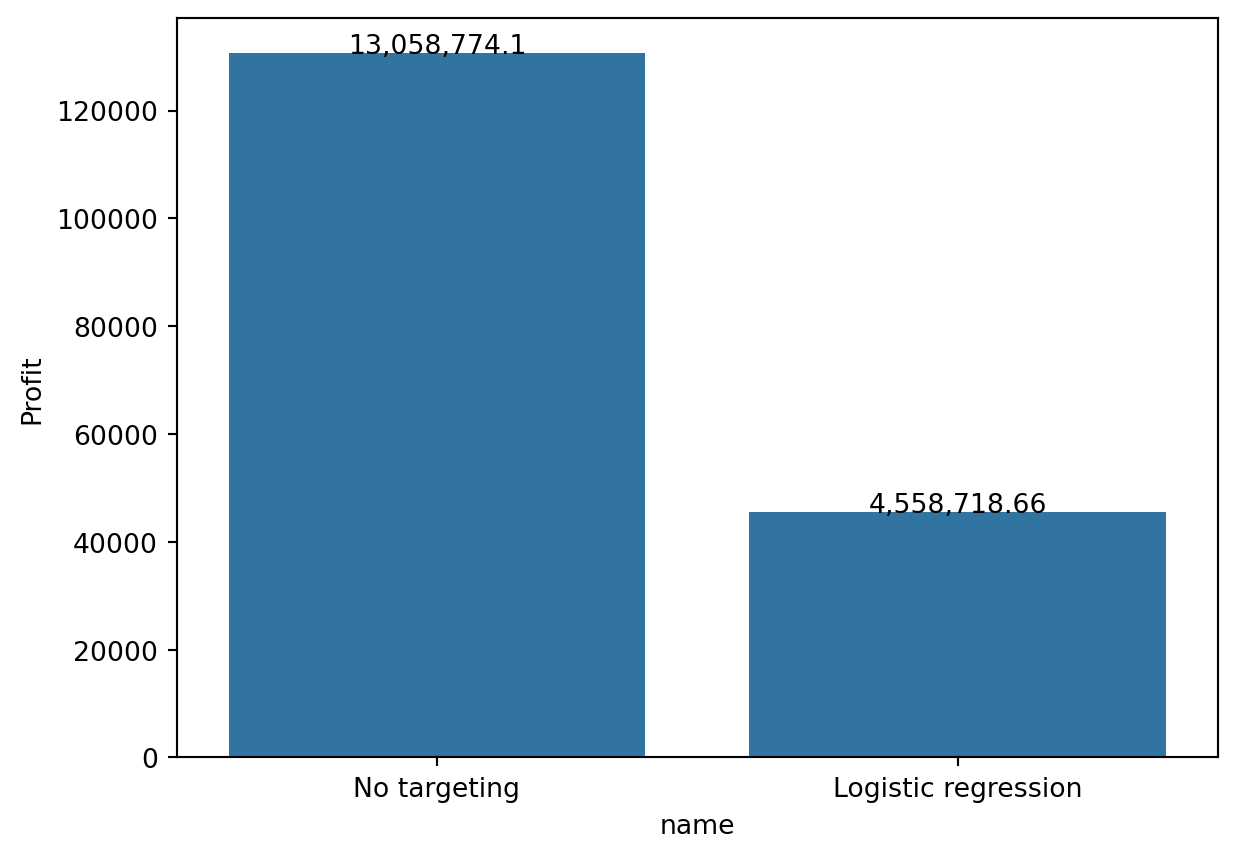

In [37]:
plt.clf()
fig = sns.barplot(x = "name", y = "Profit", data = performance_data)
for index, row in performance_data.iterrows():
    fig.text(row.name, 
             row.Profit, 
             f"{round((100*row.Profit), 2):,}", 
             color = "black", 
             ha = "center")
plt.show()

### Question 15

Create a bar chart with ROME for the analyses conducted in questions 12 and 13

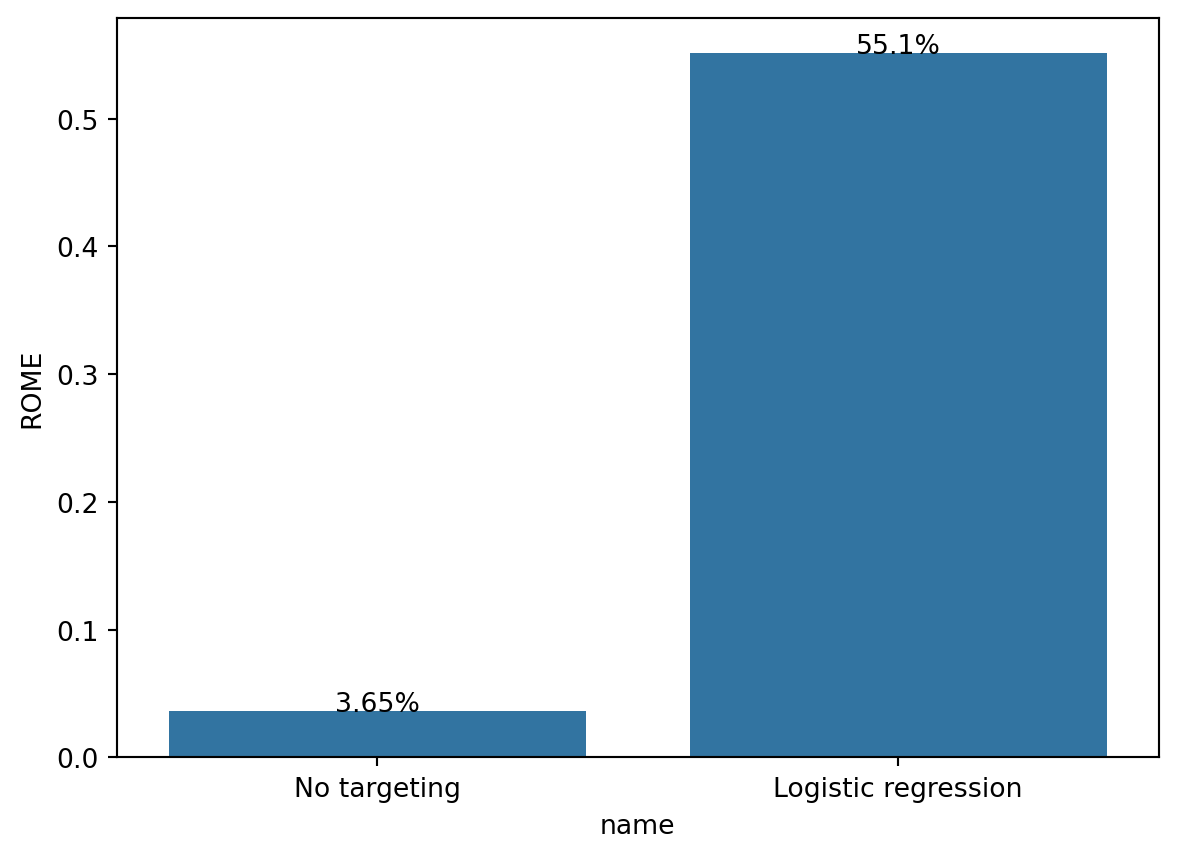

In [38]:
plt.clf()
fig = sns.barplot(x = "name", y = "ROME", data = performance_data)
for index, row in performance_data.iterrows():
    fig.text(row.name, 
             row.ROME, 
             f"{round((100*row.ROME), 2):,}%", 
             color = "black", 
             ha = "center")
plt.show()

### Question 16

You also have access to a dataset with the results from the deal offer roll-out (tuango_post.parquet). Tuango decided to contact all remaining 397,252 customers because this would provide data that could be used to evaluate different targeting approaches. The data has a "test" variable (test = 1 for the data used in the test, test = 0 for the remaining customers). Use this variable to evaluate the actual performance on the 'roll out' sample for the targeting approaches from questions 12 and 13. Also re-create the plots from question 14 and 15 based on this new dataset.

Specifically, redo questions 12-15 using the tuango-post.parquet date and make the required code adjustments to calculate the actual performance on the 'roll out' sample correctly.

Hint 1: It is important that you do NOT use any information about buyers that were in the 'roll out' sample (i.e., test == 0) when calculating the break-even response rate etc. for targeting.

Hint 2: You have the actual data on what happened in the "post" data. Use that information to calculate performance (i.e., do not "project" the performance like you had to do for questions 12 and 13).

In [39]:
tuango_post = pd.read_parquet("data/tuango_post.parquet")
tuango_post.buyer.value_counts(dropna=False)

# tuango_train = tuango_post[0:397252]
# tuango_test_rollout = tuango_post[397252:]

buyer
no     377925
yes     40235
Name: count, dtype: int64

In [40]:
# Split into train and test sets
tuango_train = tuango_post[tuango_post["test"] == 1]
tuango_test_rollout = tuango_post[tuango_post["test"] == 0]

In [41]:
lr = rsm.model.logistic(
    data = {"tuango_train": tuango_train}, rvar = "buyer", evar = ["recency", "frequency", "monetary", "age", "gender", "music"]
)

lr.summary()

Logistic regression (GLM)
Data                 : tuango_train
Response variable    : buyer
Level                : None
Explanatory variables: recency, frequency, monetary, age, gender, music
Null hyp.: There is no effect of x on buyer
Alt. hyp.: There is an effect of x on buyer

               OR     OR%  coefficient  std.error  z.value p.value     
Intercept   0.051  -94.9%        -2.98      0.097  -30.768  < .001  ***
gender[F]   1.731   73.1%         0.55      0.054   10.073  < .001  ***
gender[O]   1.078    7.8%         0.07      0.128    0.584   0.559     
music[yes]  1.908   90.8%         0.65      0.059   10.912  < .001  ***
recency     0.999   -0.1%        -0.00      0.000   -3.292  < .001  ***
frequency   1.114   11.4%         0.11      0.010   10.861  < .001  ***
monetary    1.002    0.2%         0.00      0.000   12.499  < .001  ***
age         0.988   -1.2%        -0.01      0.001   -9.115  < .001  ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo 

In [42]:
a = lr.predict(data = tuango_test_rollout)
a

,recency,frequency,monetary,age,gender,music,prediction
20908,8,1.0,115.330000,71,F,yes,0.092104
20909,274,1.0,58.000000,46,F,yes,0.083355
20910,185,8.0,123.599998,46,O,yes,0.134632
20911,127,3.0,87.810000,46,M,no,0.041179
20912,31,8.0,95.000000,33,F,yes,0.244048
...,...,...,...,...,...,...,...
418155,19,4.0,128.000000,25,F,yes,0.202410
418156,131,2.0,110.740000,20,O,yes,0.103399
418157,53,1.0,126.000000,71,M,no,0.029175
418158,12,4.0,98.000000,64,M,yes,0.077903


In [43]:
# join tuango_test_rollout and a on the index
tuango_test_rollout["pred_logit"] = a["prediction"]

/tmp/ipykernel_17749/1425206309.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tuango_test_rollout["pred_logit"] = a["prediction"]


In [44]:
q = pd.pivot_table(
    tuango_test_rollout,
    values=["ordersize"],
    index="buyer",
    aggfunc={"buyer": "count", "ordersize": ["mean","std"]},
    observed=False,
)
q.columns = ["count", "mean", "std"]

avg_ordersize = q.loc["yes", "mean"]
print(q)
print(avg_ordersize)

        count      mean       std
buyer                            
yes     38215  3.937956  1.697007
no     359037  0.000000  0.000000
3.937956299882245


In [45]:
tuango_test_rollout

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test,pred_logit
20908,U78589602,no,0.0,8,1.0,115.330000,71,F,yes,NaN,0,0.092104
20909,U83705520,no,0.0,274,1.0,58.000000,46,F,yes,NaN,0,0.083355
20910,U59772099,no,0.0,185,8.0,123.599998,46,O,yes,NaN,0,0.134632
20911,U22464840,no,0.0,127,3.0,87.810000,46,M,no,NaN,0,0.041179
20912,U36020329,no,0.0,31,8.0,95.000000,33,F,yes,NaN,0,0.244048
...,...,...,...,...,...,...,...,...,...,...,...,...
418155,U83013842,no,0.0,19,4.0,128.000000,25,F,yes,NaN,0,0.202410
418156,U45426448,no,0.0,131,2.0,110.740000,20,O,yes,NaN,0,0.103399
418157,U48935927,no,0.0,53,1.0,126.000000,71,M,no,NaN,0,0.029175
418158,U94568595,no,0.0,12,4.0,98.000000,64,M,yes,NaN,0,0.077903


In [46]:
# Example: Calculate break-even response rate (based on test sample)
cost = 9  # Example value
fees_per_sale = 49 * 0.5 * avg_ordersize
margin = fees_per_sale - cost # Example value

break_even_rate = cost / margin

# Target customers with predicted response rates >= break-even rate
tuango_test_rollout['targeted'] = (tuango_test_rollout['pred_logit'] >= break_even_rate)

# Evaluate actual response
# turn buyer into a numeric variable
# tuango_test_rollout['buyer'] = tuango_test_rollout['buyer'].map({'yes': 1, 'no': 0})


# performance = tuango_test_rollout.groupby('targeted').agg(n_obs = ("buyer", "count"))
# # performance = tuango_test_rollout.groupby('targeted').count()

# print(performance)


/tmp/ipykernel_17749/1066467394.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tuango_test_rollout['targeted'] = (tuango_test_rollout['pred_logit'] >= break_even_rate)


In [47]:
tuango_test_rollout["message_all"] = True

ncust = tuango_test_rollout.groupby("buyer", observed = False).buyer.agg("count")

all = pd.DataFrame(
    {
        "n_obs": ncust,
        "perc": ncust.agg(lambda x: (x / x.sum())),
    }
)
print(all)
tuango_test_rollout["message_logit"] = tuango_test_rollout["pred_logit"] > breakeven

nr_message_all = 397252 # total number of messages that would be sent out
message_cost_all = nr_message_all * 9 # total cost of sending messages to selected customers (float)
response_rate_all = all.loc["yes", "perc"]# expressed as a proportion (no rounding)
# response_rate_all = breakeven # expressed as a proportion (no rounding)
nr_responses_all = nr_message_all * response_rate_all # total number of positive responses
# response_rate_all = all.loc["yes", "perc"]# expressed as a proportion (no rounding)
revenue_all = 49 * avg_ordersize * nr_responses_all # total revenue in RMB (no rounding)
profit_all = 0.5 * revenue_all - message_cost_all # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
ROME_all = profit_all / message_cost_all # Return on Marketing Expenditures expressed as a proportion (no rounding)

print(nr_message_all)
print(message_cost_all)
print(response_rate_all)
print(nr_responses_all)
print(revenue_all)
print(f"Profit: {profit_all}")
print(f"ROME: {ROME_all}")

        n_obs      perc
buyer                  
yes     38215  0.096198
no     359037  0.903802
397252
3575268
0.09619838289045744
38215.0
7373961.0
Profit: 111712.5
ROME: 0.031245909397561247


/tmp/ipykernel_17749/754361132.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tuango_test_rollout["message_all"] = True
/tmp/ipykernel_17749/754361132.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tuango_test_rollout["message_logit"] = tuango_test_rollout["pred_logit"] > breakeven


In [48]:
nr_mail = tuango_test_rollout.groupby("message_logit", observed = False).message_logit.agg("count")
print(nr_mail)
some = pd.DataFrame(
    {
        "n_obs": nr_mail,
        "perc": nr_mail.agg(lambda x: (x / x.sum())),
    }
)
print(some)

response = (
    tuango_test_rollout.assign(buyer_yes = rsm. ifelse(tuango_test_rollout["buyer"] == "yes", 1, 0))
    .groupby("message_logit", observed = False)
    .agg(
        n_obs = ("buyer_yes", "count"),
        nr_buyer = ("buyer_yes", "sum"),
        perc = ("buyer_yes", "mean"),
    )
)
print(response)

nr_message_logit = response.loc[True, "n_obs"] # total number of messages that would be sent out (152822)
# nr_message_logit = some.loc[True, "n_obs"] # total number of messages that would be sent out (152822)

message_cost_logit = nr_message_logit * 9  # total cost of sending messages to selected customers (float)

nr_responses_logit = nr_message_logit * response.loc[True, "perc"]# total number of positive responses
# nr_responses_logit = nr_message_logit * some.loc[True, "perc"]# total number of positive responses
# nr_responses_logit = 174126 # total number of positive responses


response_rate_logit = nr_responses_logit / nr_message_logit # expressed as a proportion (no rounding)
# response_rate_logit = response.loc[True, "perc"] # expressed as a proportion (no rounding)

revenue_logit = 49 * avg_ordersize * nr_responses_logit # total revenue in RMB (no rounding)
profit_logit = 0.5 * revenue_logit - message_cost_logit # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
ROME_logit = profit_logit / message_cost_logit # Return on Marketing Expenditures expressed as a proportion (no rounding)

print(nr_message_logit)
print(f"Message cost: {message_cost_logit}")
print(f"number of response: {nr_responses_logit}")
print(f"Response rate: {response_rate_logit}")
print(f"Revenue: {revenue_logit}")
print(f"Profit: {profit_logit}")
print(f"ROME: {ROME_logit}") # proportion, not a percentage

message_logit
False    223126
True     174126
Name: message_logit, dtype: int64
                n_obs      perc
message_logit                  
False          223126  0.561674
True           174126  0.438326
                n_obs  nr_buyer      perc
message_logit                            
False          223126     12995  0.058241
True           174126     25220  0.144838
174126
Message cost: 1567134
number of response: 25220.0
Response rate: 0.14483764630210308
Revenue: 4866447.636268481
Profit: 866089.8181342403
ROME: 0.552658431336593


In [49]:
profit = rsm.model.profit(tuango["buyer"], tuango["pred_logit"], "yes", cost=9, margin=margin, scale=1)
profit

-1271800.5228051813

In [50]:
rome = rsm.ROME(tuango["pred_logit"], tuango["buyer_yes"], 1, cost=cost, margin=margin)
rome

-0.9253987754043843

In [51]:
rome_max = rsm.ROME_max(tuango, "buyer_yes", 1,"pred_logit", cost, margin)
rome_max

-0.9253987754043843

In [52]:
profit_tab = rsm.profit_tab(tuango, "buyer_yes", 1, "pred_logit", qnt =10, cost = cost, margin = margin, scale = 1)
profit_tab

,cum_prop,cum_profit
0,0.000000,0.000000
1,0.099866,19436.729125
2,0.199637,24807.189624
3,0.300220,30024.650124
4,0.400804,33842.431755
5,0.501339,31020.738754
6,0.601253,24379.448934
7,0.701693,19301.277771
8,0.801272,11498.268939
9,0.900995,-618.256431


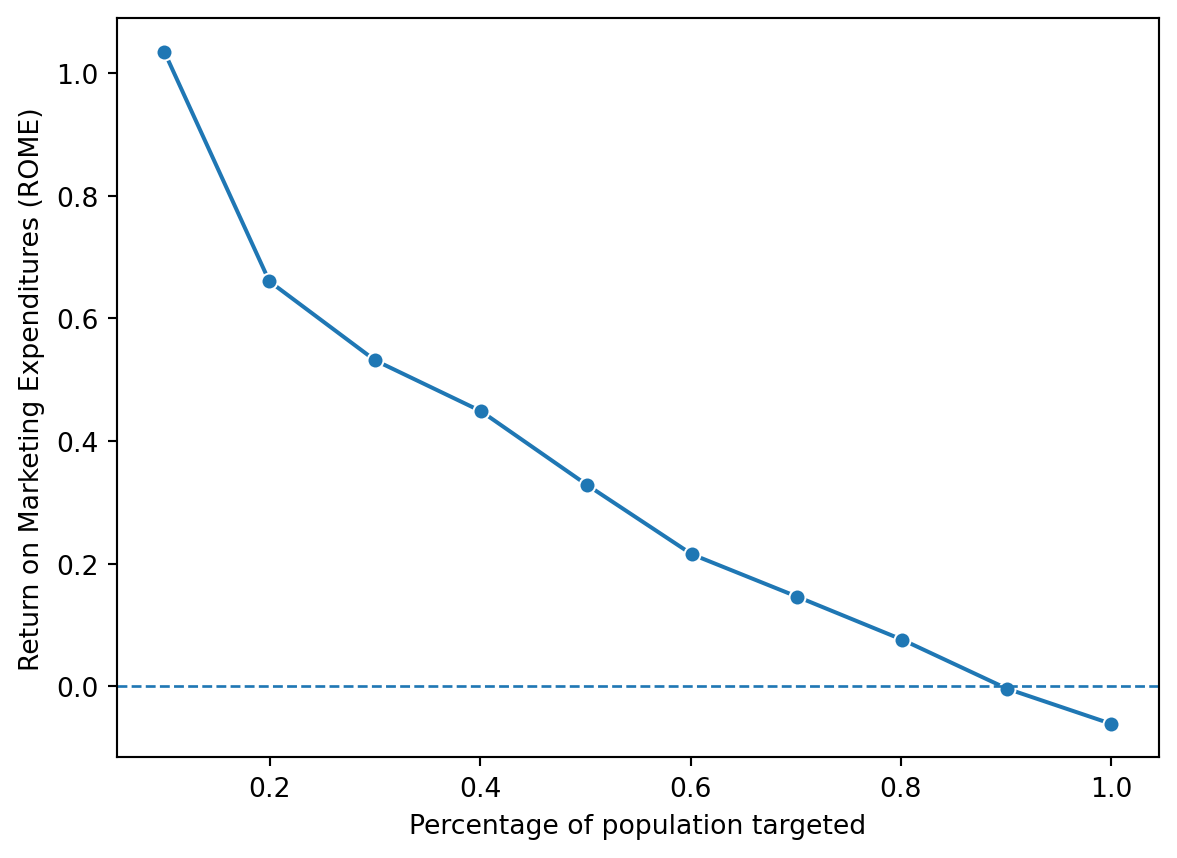

In [53]:
rome_plot = rsm.ROME_plot(tuango, "buyer_yes", 1, "pred_logit", cost = cost, margin = margin, marker = "o")

In [54]:
performance_data = pd.DataFrame(
    {
        "name": ["No targeting", "Logistic regression"],
        "Profit": [profit_all, profit_logit],
        "ROME": [ROME_all, ROME_logit],
    }
)
performance_data

,name,Profit,ROME
0,No targeting,111712.500000,0.031246
1,Logistic regression,866089.818134,0.552658


In [55]:
performance_data["Profit"] = pd.to_numeric(performance_data["Profit"])
performance_data["ROME"] = pd.to_numeric(performance_data["ROME"])
performance_data = performance_data.dropna(subset = ["Profit"])

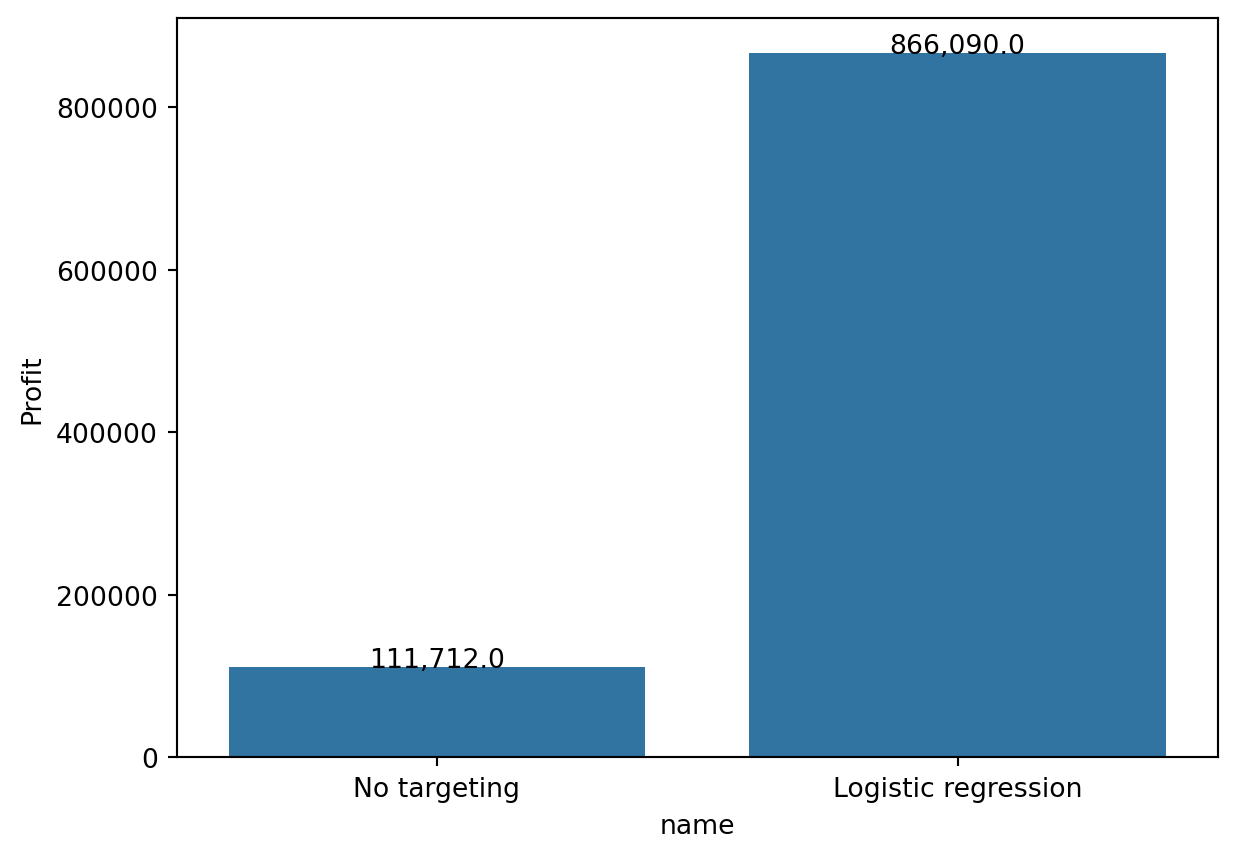

In [56]:
plt.clf()
fig = sns.barplot(x = "name", y = "Profit", data = performance_data)
for index, row in performance_data.iterrows():
    fig.text(row.name, 
             row.Profit, 
             f"{round((row.Profit), 0):,}", 
             color = "black", 
             ha = "center")

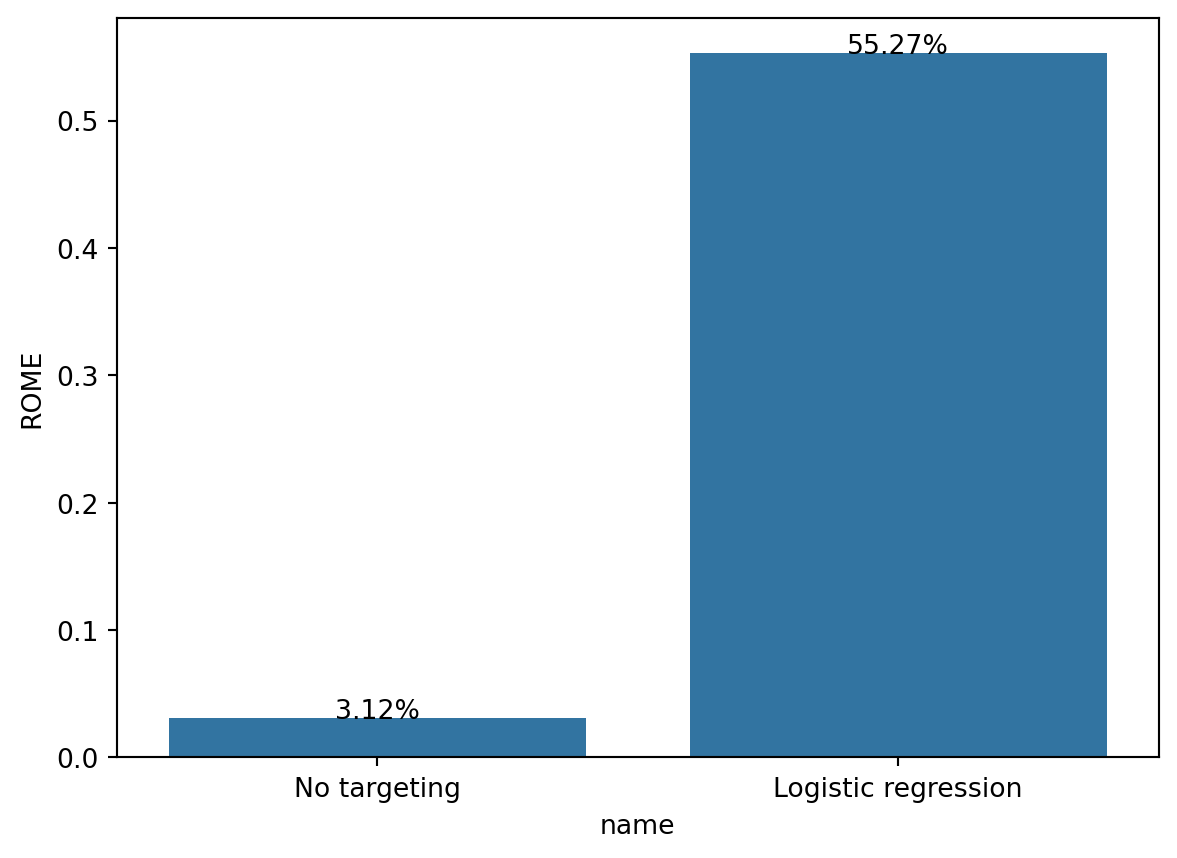

In [57]:
plt.clf()
fig = sns.barplot(x = "name", y = "ROME", data = performance_data)
for index, row in performance_data.iterrows():
    fig.text(row.name, 
             row.ROME, 
             f"{round((100*row.ROME), 2):,}%", 
             color = "black", 
             ha = "center")

In [58]:
tuango.loc[
    (tuango.message_logit == True) & (tuango.test == 0),
    ["userid", "message_logit", "pred_logit"]
]

,userid,message_logit,pred_logit
20910,U59772099,True,0.134632
20912,U36020329,True,0.244048
20914,U41061867,True,0.107997
20915,U45367432,True,0.116449
20919,U72456768,True,0.094480
...,...,...,...
418152,U86443367,True,0.122552
418154,U68362853,True,0.094248
418155,U83013842,True,0.202410
418156,U45426448,True,0.103399
